In [1]:
# ===============================================================
# Compare Pushforward Models vs pCN Posterior in KL Coordinates
# ===============================================================
# loading libraries:
import os, torch, numpy as np, h5py, scipy.io as sio, matplotlib.pyplot as plt
from scipy.stats import norm
from FNOmodel import CosineFNO1d, FNOTripletAdapter1d   # adjust import paths
from scipy.stats import gaussian_kde
import numpy as np
# from FNOmodel import CosineFNO2d, FNOTripletAdapter
pushforwardtype = "fromprior"
if pushforwardtype =="fromjoint":
    from FNOmodel import *
    Cin=3
elif pushforwardtype=="fromprior":
    from FNOmodel_2inputchannel import *
    Cin=2

from scipy.spatial.distance import cdist
from helper import *
def energy_distance_mc(X, Y, n_xy=5000, n_xx=5000, n_yy=5000,seed=None):
    # need to remember why did I need this
    rng = np.random.default_rng(seed)
    # X–Y pairs
    i = rng.integers(0, len(X), size=n_xy)
    j = rng.integers(0, len(Y), size=n_xy)
    d_xy = np.linalg.norm(X[i] - Y[j], axis=1).mean()

    # X–X pairs
    i = rng.integers(0, len(X), size=n_xx)
    j = rng.integers(0, len(X), size=n_xx)
    d_xx = np.linalg.norm(X[i] - X[j], axis=1).mean()

    # Y–Y pairs
    i = rng.integers(0, len(Y), size=n_yy)
    j = rng.integers(0, len(Y), size=n_yy)
    d_yy = np.linalg.norm(Y[i] - Y[j], axis=1).mean()

    return 2*d_xy - d_xx - d_yy
    

In [2]:
# loading data:
# loading the data
file_path = "./../../Data/Experiment7/samples_wave_center.npz"
f=np.load(file_path)
use_cm = False
cm_alpha = f['alpha'].item()
cm_tau =   f['tau'].item()
cm_scale = f['scale'].item()


In [3]:
f

NpzFile './../../Data/Experiment7/samples_wave_center.npz' with keys: U, arrival, x_nodes, t_grid, recv_idx...

In [4]:
sigma_obs = 5e-3
DEBUG = True
Nsol, Nobs = 100, 10
thin_pCN=True
thin_pCN_spacing=1000


In [5]:
# -------------------------------
# Configuration
# -------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
# pushforward_paths = {
#     "T_CM_ON": "./../../Models/Experiment5/CosineFNO_cmON_fromjoint_B64_lr1e-3_E15_s42_depth5_width_80_modes_x32_200_1D_1e6withlrdecay_20260327_1215.pth",
#     "T_CM_OFF": "./../../Models/Experiment5/CosineFNO_cmOFF_fromjoint_B64_lr1e-3_E15_s42_depth5_width_80_modes_x32_200_1D_1e6withlrdecay_20260328_0905.pth",
#     } # from prior
    

# pushforward_paths = {
#     "T_CM_ON": "./../../Models/Experiment5/CosineFNO_cmON_fromprior_B64_lr1e-3_E15_s42_depth5_width_80_modes_x32_200_1D_1e6withlrdecay_20260323_2027.pth",
#     "T_CM_OFF": "./../../Models/Experiment5/CosineFNO_cmOFF_fromprior_B64_lr1e-3_E15_s42_depth5_width_80_modes_x32_200_1D_1e6withlrdecay_20260324_1953.pth",
#     } # from prior

pushforward_paths = {
    # "T_CM_ON": "./../../Models/Experiment7/CosineFNO_cmON_fromprior_B80_lr1e-3_E15_s42_depth5_width_100_modes_x32_200_1D_1e6withlrdecay_20260629_0635.pth",
    "T_CM_OFF": "./../../Models/Experiment7/CosineFNO_cmOFF_fromprior_B80_lr1e-3_E15_s42_depth5_width_100_modes_x32_200_1D_1e6withlrdecay_20260628_2035.pth",
    } # from prior
    


iteration_data = -6  # set to an int for iterative runs (e.g. 6), None for the base run
# file_true = "./../../Data/Experiment7/wave.npz" # This is for when the data came before

file_true = "./../../Data/Experiment7/wave_iteration"+str(iteration_data)+".npz" # This is for when the data came before
pCN_chain_dir = "./../../Data/Experiment7/pcn_chain0.2iteration_datapoint"+str(iteration_data)+".npz"
# pCN_chain_dir = "./../../Data/Experiment7/pcn_chain0.15.npz" # This is for when iteration_data=0




In [6]:
string_models=["T_CM_OFF"]

In [7]:
# -------------------------------
# Load Data (x,y)
# -------------------------------
x= f["U"]
y= f["arrival"]

np.random.seed(1373)
y_noisy = y + np.random.normal(0, sigma_obs, size=y.shape)
n_total = x.shape[-1]
half = 9*(n_total) // 12
debeug_length=30000
if DEBUG==True:
    x_joint = x[:, half:half+debeug_length].T.astype(np.float32)
    y_joint = y_noisy[:,  half:half+debeug_length].T.astype(np.float32)
else:
    x_joint = x[:, half:].T.astype(np.float32)
    y_joint = y_noisy[:,  half:].T.astype(np.float32)


In [8]:
x_joint.shape

(30000, 100)

In [9]:
y_joint.shape

(30000, 10)

In [10]:
# -------------------------------
# Load true (x*, y†)
# -------------------------------
true_data = np.load(file_true)
x_true = true_data["u_true"].reshape(Nsol, 1)
y_dagger = true_data["y_obs"].reshape(Nobs, 1)

Text(0.5, 0, 'i')

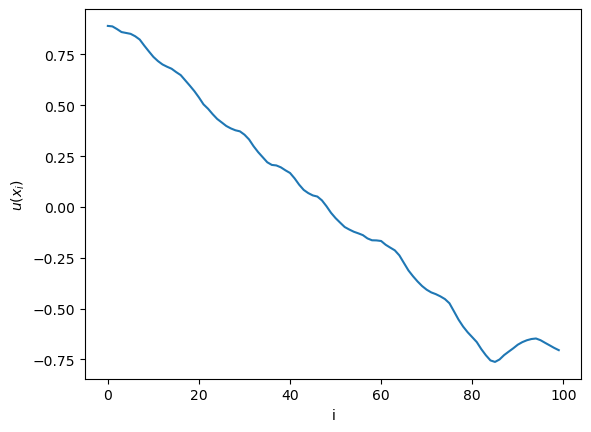

In [11]:
plt.plot(x_true)
plt.ylabel(r"$u(x_i)$")
plt.xlabel("i")


Text(0.5, 0, 'i')

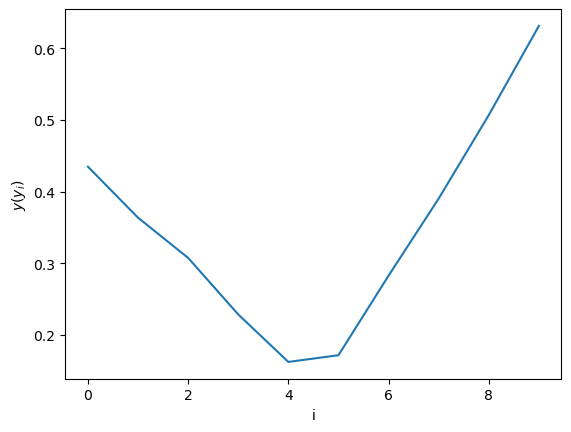

In [12]:
plt.plot(y_dagger)
plt.ylabel(r"$y(y_i)$")
plt.xlabel("i")


In [13]:
N=x_joint.shape[0]
y_dag_vec   = y_dagger.reshape(Nobs)              # (Nobs,)
y_dag_batch = np.repeat(y_dag_vec[None, :], N, axis=0)  # (N, Nobs)
# --- to torch ---
x_t      = torch.from_numpy(x_joint).float().to(device)
y_t      = torch.from_numpy(y_joint).float().to(device)
y_dag_t  = torch.from_numpy(y_dag_batch).float().to(device)


In [14]:

def build_phi_lambda(Nsol, tau, alpha, scale):
    # grid points x_j = (2j - 1)/(2 Nsol),  j = 1..Nsol
    j = np.arange(1, Nsol + 1)
    x_spatial = (2*j - 1) / (2 * Nsol)   # shape (Nsol,)

    # mode indices i = 1..Nsol
    i = np.arange(1, Nsol + 1)   # shape (Nsol,)

    # Phi[j, i] = sqrt(2) * cos(i * pi * x_j)
    # Use broadcasting: x[:,None] (Nsol,1), i[None,:] (1,Nsol)
    Phi = np.sqrt(2.0) * np.cos(np.pi * x_spatial[:, None] * i[None, :])

    # lambda_i = ((i*pi)^2 + tau^2)^(-alpha)
    lambdas = scale**2*((i * np.pi)**2 + tau**2)**(-alpha)

    return x_spatial, Phi[:,:-1], lambdas[:-1]

x_spatial, Phi, lambdas = build_phi_lambda (Nsol , cm_tau, cm_alpha, cm_scale)


In [15]:
L=1
x_center=x_spatial
Np1=x_center.shape[0]+1
i = np.arange(0, Np1 )
dx=L/(Np1-1)
x_nodes = i*dx

In [16]:
# checking if the eigenfunctions are calculated correctly. 
# The standard deviation of the samples should be sqrt of lambda along each eigen modes.
dx = 1.0 / Nsol
coeffs = dx * Phi.T @ x
# --- empirical std along each mode ----
std_emp = np.std(coeffs, axis=1, ddof=0)     # (Nsol,)
std_theory = np.sqrt(lambdas)                # (Nsol,)
rel_err = np.abs(std_emp - std_theory) / std_theory
print("Mode  EmpStd   ThStd   RelErr")
for k in range(Nsol-1):
    print(f"{k+1:3d}  {std_emp[k]:.4e}  {std_theory[k]:.4e}  {rel_err[k]:.3e}")


Mode  EmpStd   ThStd   RelErr
  1  2.8680e-01  2.8678e-01  4.950e-05
  2  1.5505e-01  1.5509e-01  2.305e-04
  3  8.7831e-02  8.7853e-02  2.522e-04
  4  5.4673e-02  5.4671e-02  3.703e-05
  5  3.6794e-02  3.6800e-02  1.579e-04
  6  2.6297e-02  2.6295e-02  9.026e-05
  7  1.9658e-02  1.9661e-02  1.537e-04
  8  1.5220e-02  1.5229e-02  5.955e-04
  9  1.2124e-02  1.2129e-02  4.383e-04
 10  9.8866e-03  9.8818e-03  4.872e-04
 11  8.2031e-03  8.2020e-03  1.435e-04
 12  6.9112e-03  6.9146e-03  4.795e-04
 13  5.9098e-03  5.9068e-03  5.064e-04
 14  5.1004e-03  5.1035e-03  6.042e-04
 15  4.4528e-03  4.4530e-03  4.154e-05
 16  3.9200e-03  3.9191e-03  2.393e-04
 17  3.4738e-03  3.4755e-03  4.732e-04
 18  3.1022e-03  3.1029e-03  2.464e-04
 19  2.7876e-03  2.7871e-03  1.726e-04
 20  2.5188e-03  2.5171e-03  6.759e-04
 21  2.2827e-03  2.2844e-03  7.343e-04
 22  2.0831e-03  2.0825e-03  2.719e-04
 23  1.9058e-03  1.9062e-03  2.207e-04
 24  1.7512e-03  1.7513e-03  1.107e-04
 25  1.6140e-03  1.6146e-03  3.492

In [17]:
# loading posterior samples:
pCNchain=np.load(pCN_chain_dir)["chain"].T
print("projection to the constant eigen mode is: " ,np.sum(np.mean(pCNchain,axis=1)) )
print("This needs to be zero because we have excluded that mode from the data")


projection to the constant eigen mode is:  2.8033131371785203e-14
This needs to be zero because we have excluded that mode from the data


In [18]:
pCNchain.shape

(100, 2500000)

In [19]:

if thin_pCN:
    pCNchain=pCNchain[:,::thin_pCN_spacing]

Now its time to load the model, run the pushforward and then compare the distribution of the samples. Please work so that I can work on a new project.

In [20]:
pCNchain.shape

(100, 2500)

In [21]:
string_models

['T_CM_OFF']

In [22]:
c_high = np.exp(0.27)
c_low  = np.exp(-0.27)


def samples_to_physical_c(
    U_samples_center,
    x_center,
    x_nodes,
    c_high,
    c_low,
):
    """
    Convert samples from center-grid latent field U to physical-space c(x).

    Parameters
    ----------
    U_samples_center : ndarray, shape (Ncenter, Nsamp)
        Samples in the center basis/grid.
    x_center : ndarray, shape (Ncenter,)
        Grid where U_samples_center is defined.
    x_nodes : ndarray, shape (Nnodes,)
        Physical-space grid where c(x) is desired.

    Returns
    -------
    C_samples : ndarray, shape (Nnodes, Nsamp)
        Physical-space wave-speed samples.
    """
    Nsamp = U_samples_center.shape[1]
    Nnodes = len(x_nodes)

    C_samples = np.zeros((Nnodes, Nsamp))

    for i in range(Nsamp):
        U_sample = np.interp(x_nodes, x_center, U_samples_center[:, i])
        c_sample = levelset_to_c_binary(U_sample,c_high=c_high,c_low=c_low)
        C_samples[:, i] = c_sample

    return C_samples

In [23]:
def plot_physical_c_uncertainty(
    x_nodes,
    c_true,
    C_pcn,
    C_ml,
    model_label,
    savepath=None,
):
    """
    Plot mean and uncertainty bands of c(x) for pCN and one ML model.
    """
    pcn_mean = C_pcn.mean(axis=1)
    pcn_std  = C_pcn.std(axis=1)

    ml_mean = C_ml.mean(axis=1)
    ml_std  = C_ml.std(axis=1)

    plt.figure(figsize=(12, 5))

    # True field
    if c_true is not None:
        plt.plot(x_nodes, c_true, 'r-', lw=2, label='True')

    # pCN
    plt.plot(x_nodes, pcn_mean, 'b-', lw=1.5, label='pCN mean')
    plt.plot(x_nodes, pcn_mean + pcn_std, 'b--', lw=1, label='pCN ±1σ')
    plt.plot(x_nodes, pcn_mean - pcn_std, 'b--', lw=1)
    plt.plot(x_nodes, pcn_mean + 2*pcn_std, 'b:', lw=1, label='pCN ±2σ')
    plt.plot(x_nodes, pcn_mean - 2*pcn_std, 'b:', lw=1)

    # ML
    plt.plot(x_nodes, ml_mean, 'g-', lw=1.5, label=f'{model_label} mean')
    plt.plot(x_nodes, ml_mean + ml_std, 'g--', lw=1, label=f'{model_label} ±1σ')
    plt.plot(x_nodes, ml_mean - ml_std, 'g--', lw=1)
    plt.plot(x_nodes, ml_mean + 2*ml_std, 'g:', lw=1, label=f'{model_label} ±2σ')
    plt.plot(x_nodes, ml_mean - 2*ml_std, 'g:', lw=1)

    plt.xlabel("x")
    plt.ylabel("c(x)")
    plt.title(f"Physical-space uncertainty: pCN vs {model_label}")
    plt.xlim([x_nodes.min(), x_nodes.max()])
    plt.legend()
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()

In [24]:
# Convert pCN once outside the loop 
C_pcn = samples_to_physical_c(
    U_samples_center=pCNchain,
    x_center=x_center,
    x_nodes=x_nodes,
    c_high=c_high,
    c_low=c_low,

)

# True c field if you have x_true in U-space
U_true_interp = np.interp(x_nodes, x_center, np.squeeze(x_true))
c_true = levelset_to_c_binary(
    U_true_interp,
    c_high,
    c_low,
)

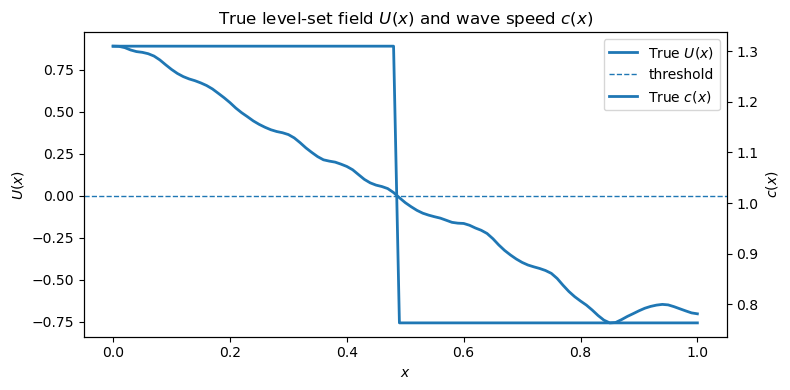

In [25]:
# Plot true U and true c on the same figure
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(x_nodes, U_true_interp, label=r"True $U(x)$", linewidth=2)
ax1.axhline(0.0, linestyle="--", linewidth=1, label="threshold")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$U(x)$")

ax2 = ax1.twinx()
ax2.plot(x_nodes, c_true, label=r"True $c(x)$", linewidth=2)
ax2.set_ylabel(r"$c(x)$")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title(r"True level-set field $U(x)$ and wave speed $c(x)$")
plt.tight_layout()
plt.show()

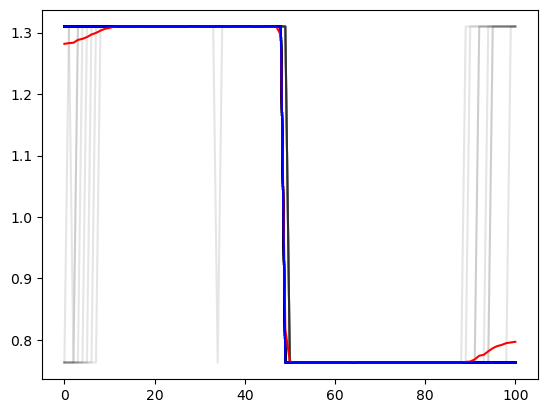

In [26]:
for i in range(C_pcn.shape[0]):
    plt.plot(C_pcn[:,i],color="black",alpha=.1)
mean_pcn=np.mean(C_pcn,axis=1)
plt.plot(mean_pcn,color="red")
plt.plot(c_true,color="blue")

In [27]:
x_true.shape

(100, 1)

In [28]:
U_true_interp = np.interp(x_nodes, x_center, np.squeeze(x_true))


/tmp/ipykernel_1763697/2288268822.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(pushforward_paths[strings], map_location=device)


✅ Model loaded and ready for inference
(30000, 100) (30000, 10) (10, 1)
T_CM_OFF
pushforward_samples shape: torch.Size([30000, 100])


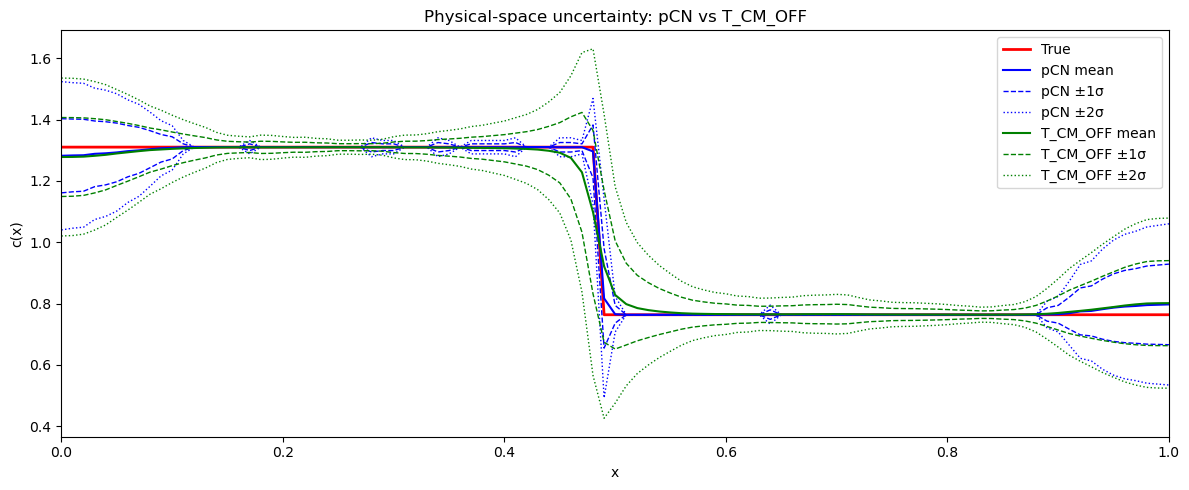

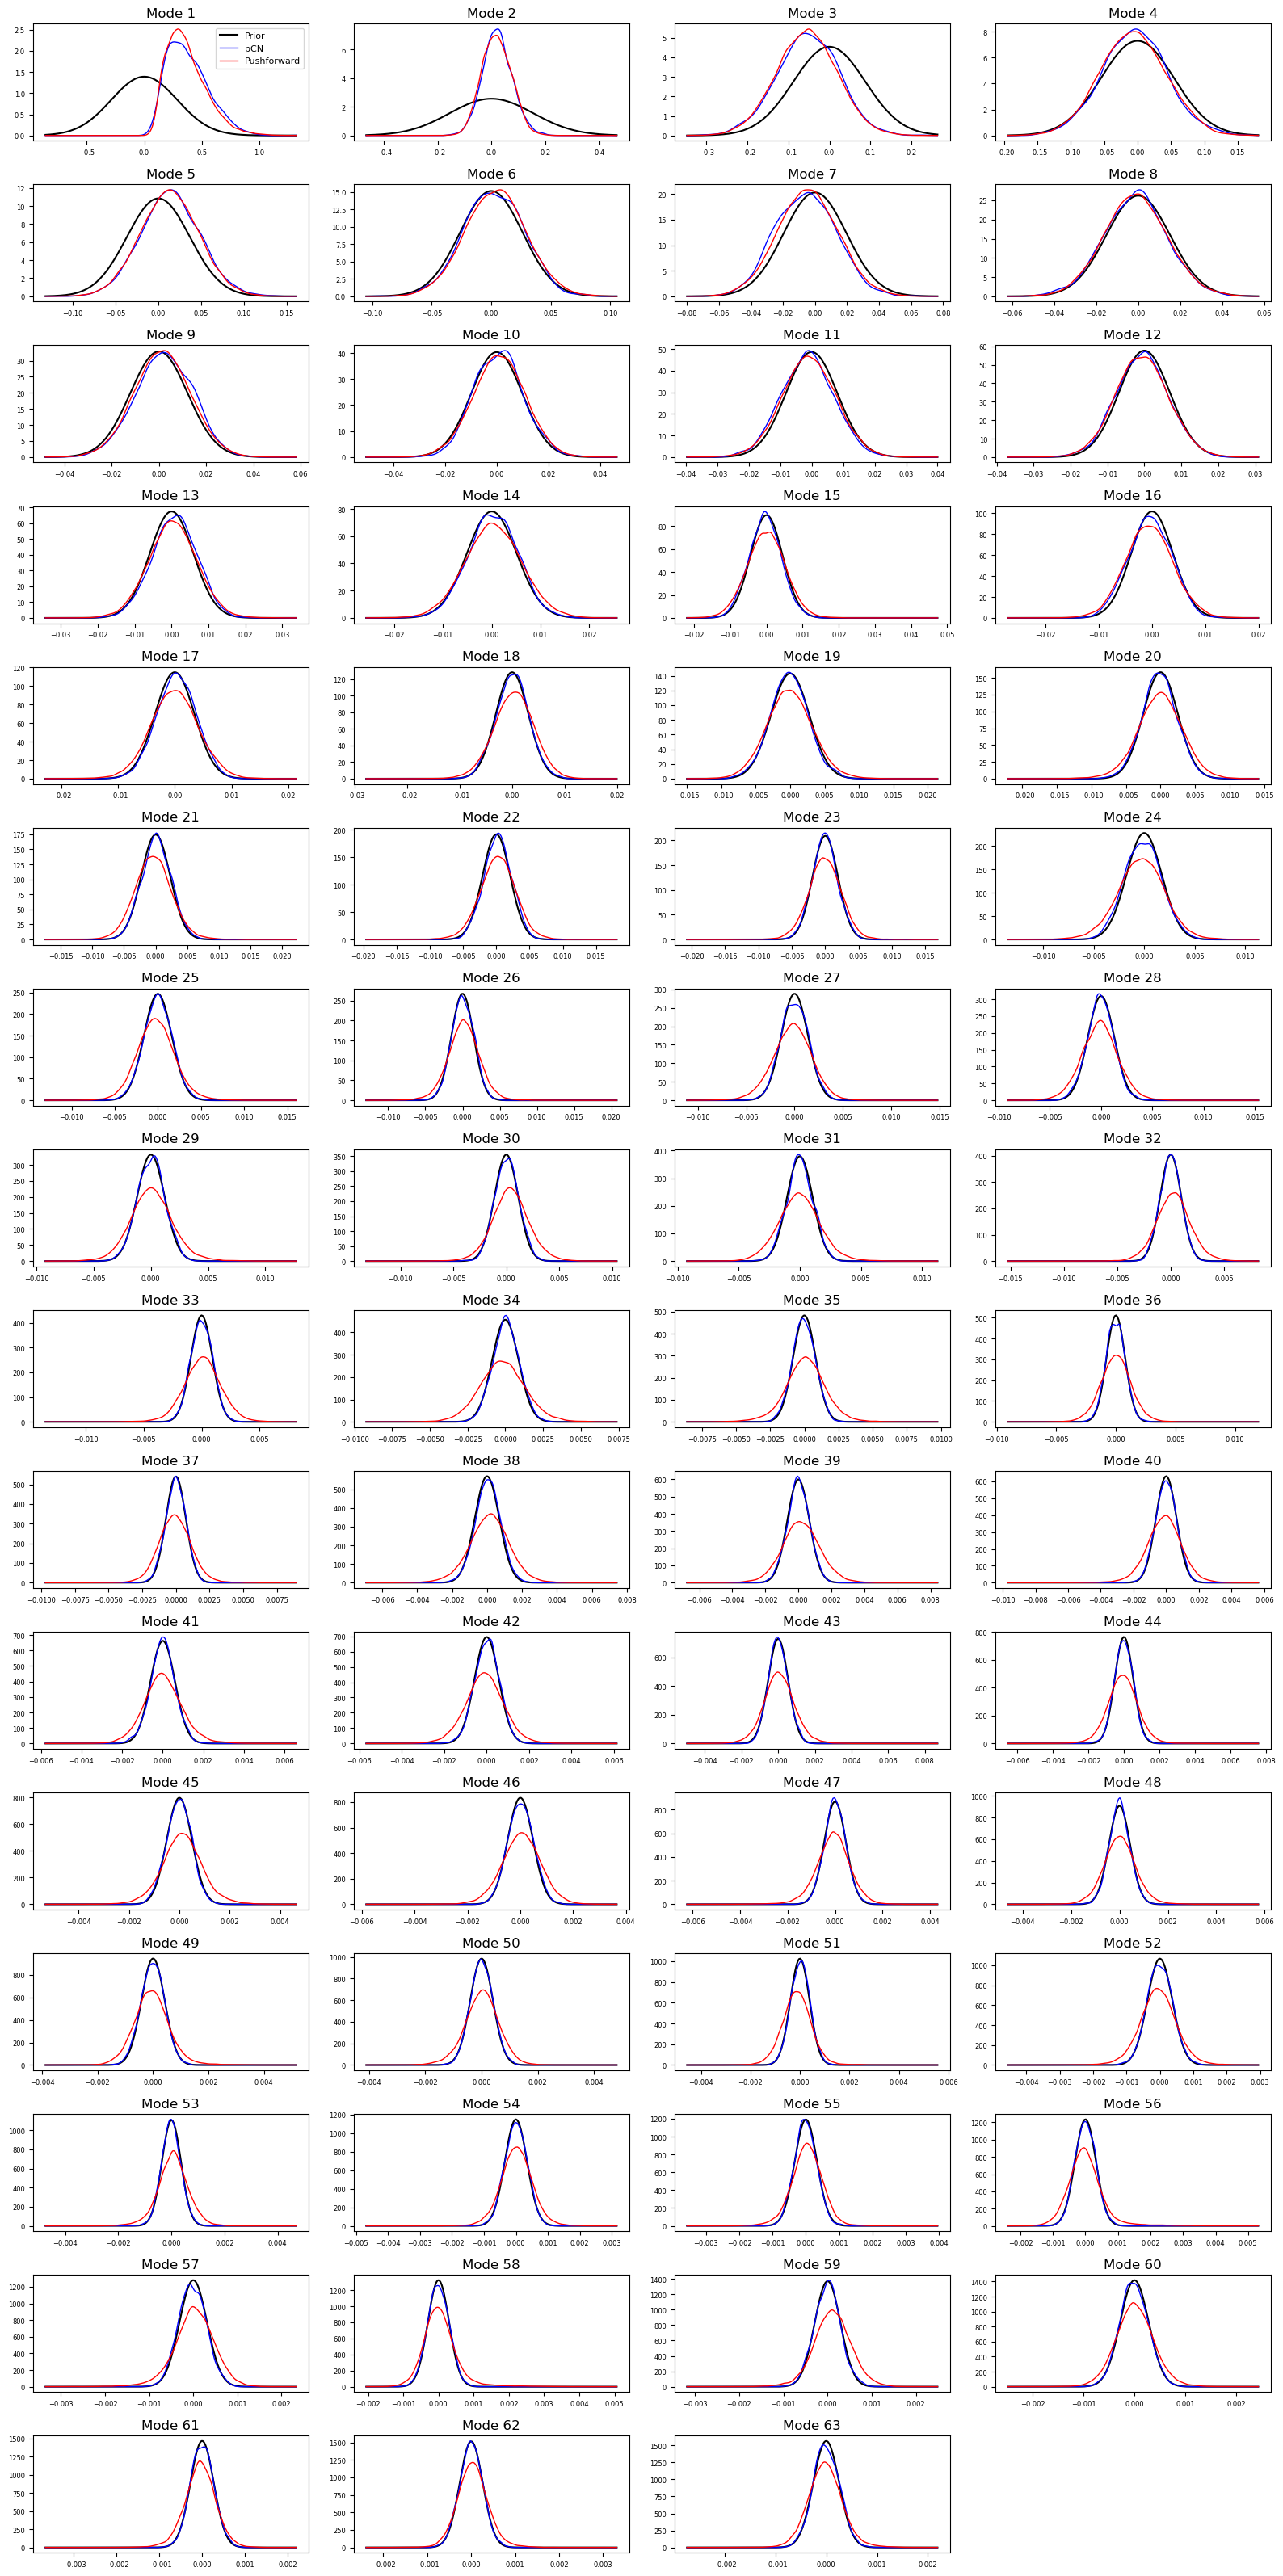

In [29]:
from scipy.stats import wasserstein_distance
# -----------------------------------------
# Load checkpoint
# -----------------------------------------
wasserstein_results = {}

for strings in string_models:
    ckpt = torch.load(pushforward_paths[strings], map_location=device)
    cfg = ckpt["config"]
    mean_std = ckpt["mean_std"]

    # -----------------------------------------
    # Rebuild base model
    # -----------------------------------------
    base = CosineFNO1d(
        Cin      = Cin,                     # <<< replace if different
        Cout     = 1,                     # <<< replace if different
        width    = cfg["width"],
        modes_x  = cfg["modes_x"],
        Lx       = 1.0,                   # <<< replace with your Lx
        depth    = cfg["depth"],
        use_cm   = cfg["use_cm"],
        cm_alpha = cfg["cm_alpha"],
        cm_tau   = cfg["cm_tau"],
        cm_scale = cfg["cm_scale"],
        dropout  = cfg["dropout"],
    )

    # Wrap with correct adapter
    if cfg["pushforwardtype"] == "fromjoint":
        model = FNOTripletAdapter1d(
        base,
        mean_std['mean_u'], mean_std['std_u'],
        mean_std['mean_y'], mean_std['std_y']).to(device)
    elif pushforwardtype=="fromprior":
        model = FNO2Adapter1d(
        base,
        mean_std['mean_u'], mean_std['std_u'],
        mean_std['mean_y'], mean_std['std_y']).to(device)


    model = model.to(device)

    # -----------------------------------------
    # Load weights
    # -----------------------------------------
    model.load_state_dict(ckpt["model_state_dict"])

    model.eval()
    print("✅ Model loaded and ready for inference")
    print(x_joint.shape,y_joint.shape,y_dagger.shape)
    print(strings)
    with torch.no_grad():
        model.eval()

        B = x_t.shape[0]
        n_chunks = 100
        chunk_size = B // n_chunks   # 10000 // 10 = 1000

        outputs = []

        for i in range(n_chunks):
            start = i * chunk_size
            end   = (i + 1) * chunk_size if i < n_chunks - 1 else B

            xb = x_t[start:end].to(device)
            yb = y_t[start:end].to(device)
            ydagb = y_dag_t[start:end].to(device)

            with torch.no_grad():
                # For FNOTripletAdapter1d: (x_joint, y_joint, y_dag_batch)
                if cfg["pushforwardtype"] == "fromjoint":
                    pushforward_samples = model(xb, yb, ydagb)   # shape depends on your adapter
                else:
                    pushforward_samples = model(xb, ydagb)

            outputs.append(pushforward_samples.detach().cpu())

        pushforward_samples = torch.cat(outputs, dim=0)

    print("pushforward_samples shape:", pushforward_samples.shape)
    pushforward_samples=pushforward_samples.detach().cpu().numpy().T
    C_push = samples_to_physical_c(
    U_samples_center=pushforward_samples,
    x_center=x_center,
    x_nodes=x_nodes,
    c_high=c_high,
    c_low=c_low,)

    plot_physical_c_uncertainty(
    x_nodes=x_nodes,
    c_true=c_true,
    C_pcn=C_pcn,
    C_ml=C_push,
    model_label=strings,
    savepath=f"physical_space_{strings}.png",)
    
    # find distance between two distribution (MCMC and the pushforward):
    # samples1=pushforward_samples.T
    # samples2=pCNchain.T
    # energy_distance_mc(samples1, samples2, n_xy=100000, n_xx=100000, n_yy=100000)

    dx = 1.0 / Nsol
    pcn_proj   = dx * Phi.T @ pCNchain          # (Nmodes, Nsamp_pcn)
    push_proj  = dx * Phi.T @ pushforward_samples              # (Nmodes, Npush)


    n_modes_wass = pcn_proj.shape[0]
    wass_per_mode = []

    for i in range(n_modes_wass):
        pcn_i  = pcn_proj[i, :]
        push_i = push_proj[i, :]
        w_i = wasserstein_distance(pcn_i, push_i)
        wass_per_mode.append(w_i)

    wasserstein_results[strings] = {
        "per_mode": np.array(wass_per_mode),
        "mean": np.mean(wass_per_mode),
        "sum": np.sum(wass_per_mode),
    }




    n_rows, n_cols = 16, 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 32))
    axes = axes.ravel()
    # ---------------------------------------------------
    # 3) Loop over modes and plot prior + KDEs
    # ---------------------------------------------------
    for i in range(64):  # 0..62 if Nmodes=63
        ax = axes[i]

        # Samples along mode i
        pcn_i   = pcn_proj[i, :]    # (Nsamp_pcn,)
        push_i  = push_proj[i, :]   # (Npush,)

        # Theoretical prior N(0, lambda_i)
        lam_i = lambdas[i]
        std_i = np.sqrt(lam_i)

        # Set x-range based on samples and theory
        all_vals = np.concatenate([pcn_i, push_i])
        x_min = min(all_vals.min(), -3*std_i)
        x_max = max(all_vals.max(),  3*std_i)
        xs = np.linspace(x_min, x_max, 200)

        # Prior density
        prior_pdf = (1.0 / (np.sqrt(2*np.pi)*std_i)) * np.exp(-0.5 * (xs/std_i)**2)
        ax.plot(xs, prior_pdf, 'k-', lw=1.5, label='Prior')

        # KDE for pCN samples
        kde_pcn = gaussian_kde(pcn_i)
        ax.plot(xs, kde_pcn(xs), 'b-', lw=1, label='pCN')

        # KDE for pushforward samples
        kde_push = gaussian_kde(push_i)
        ax.plot(xs, kde_push(xs), 'r-', lw=1, label='Pushforward')

        ax.set_title(f"Mode {i+1}")
        ax.tick_params(axis='both', labelsize=6)

    # Optional: add a single legend in the last axis
    axes[0].legend(fontsize=8)
    fig.delaxes(axes[-1])
    plt.tight_layout()
    # plt.savefig("64modes_grid"+strings+".png", dpi=300)
    plt.show()



In [30]:
pushforward_samples.shape

(100, 30000)

In [31]:
iter_tag = f"_iteration-{iteration_data}" if iteration_data is not None else ""


In [32]:
print("projection to the constant eigen mode is: "+f"{iter_tag}"+"CM"+str(use_cm) ,np.sum(np.mean(pushforward_samples,axis=1)) )


projection to the constant eigen mode is: _iteration--6CMFalse -0.22556624


In [33]:
print("projection to the constant eigen mode is: "+f"{iter_tag}"+"CM"+str(use_cm) ,np.sum(np.mean(pushforward_samples,axis=1)) )


projection to the constant eigen mode is: _iteration--6CMFalse -0.22556624


In [34]:
np.savez_compressed(f"./../../Data/Experiment7/wasserstein_{strings}CM"+str(use_cm)+f"{iter_tag}.npz", **wasserstein_results[strings])

In [35]:
iter_tag 


'_iteration--6'

In [36]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Example:
# # wasserstein_results[model_name]["per_mode"] = array of shape (n_modes_wass,)

# cm_on_curves = []
# cm_off_curves = []

# cm_on_names = []
# cm_off_names = []

# for model_name, vals in wasserstein_results.items():
#     curve = np.array(vals["per_mode"])

#     # adjust this logic to match your naming convention
#     if "cmon" in model_name.lower() or "cm_on" in model_name.lower():
#         cm_on_curves.append(curve)
#         cm_on_names.append(model_name)
#     elif "cmoff" in model_name.lower() or "cm_off" in model_name.lower():
#         cm_off_curves.append(curve)
#         cm_off_names.append(model_name)

# cm_on_curves = np.array(cm_on_curves)    # (n_models_on, n_modes)
# cm_off_curves = np.array(cm_off_curves)  # (n_models_off, n_modes)

# mean_cm_on = cm_on_curves.mean(axis=0)
# mean_cm_off = cm_off_curves.mean(axis=0)

# modes = np.arange(1, len(mean_cm_on) + 1)

# plt.figure(figsize=(6,4))
# plt.plot(modes, mean_cm_on, label="CM on", linewidth=2)
# plt.plot(modes, mean_cm_off, label="CM off", linewidth=2)
# plt.xlabel("Mode")
# plt.ylabel("Wasserstein distance")
# plt.legend()
# plt.tight_layout()
# # plt.savefig("wasserstein_vs_mode_CM_on_off.png", dpi=300, bbox_inches="tight")
# # plt.xlim(left=0,right=50)
# plt.yscale("log")
# plt.show()



In [37]:
# print(x_t.shape, y_t.shape, y_dag_t.shape)

In [38]:
# y_dag_t.shape

In [39]:
# samples1.shape

In [40]:
# for i in range(N):
#     plt.plot(pushforward_samples[:,i],color='black',alpha=.1)
# plt.plot(x_true,color='red')

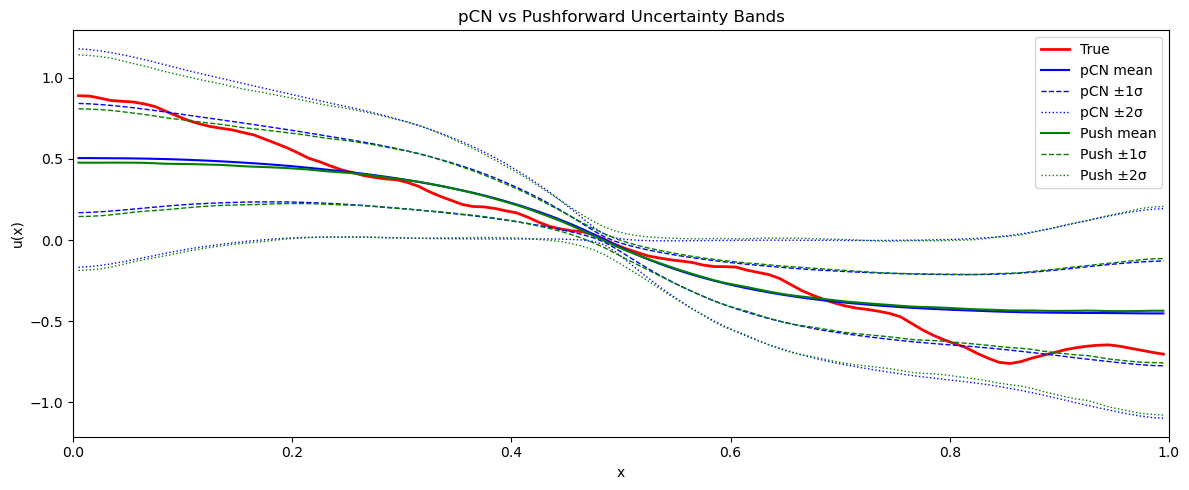

In [41]:
# Means & std
pcn_mean  = pCNchain.mean(axis=1)
pcn_std   = pCNchain.std(axis=1)

push_mean = pushforward_samples.mean(axis=1)
push_std  = pushforward_samples.std(axis=1)

plt.figure(figsize=(12,5))

# --- True ---
plt.plot(x_spatial, x_true, 'r-', lw=2, label="True")

# --- pCN mean + std lines ---
plt.plot(x_spatial, pcn_mean, 'b-', lw=1.5, label="pCN mean")
plt.plot(x_spatial, pcn_mean + pcn_std, 'b--', lw=1, label="pCN ±1σ")
plt.plot(x_spatial, pcn_mean - pcn_std, 'b--', lw=1)
plt.plot(x_spatial, pcn_mean + 2*pcn_std, 'b:', lw=1, label="pCN ±2σ")
plt.plot(x_spatial, pcn_mean - 2*pcn_std, 'b:', lw=1)

# --- pushforward mean + std lines ---
plt.plot(x_spatial, push_mean, 'g-', lw=1.5, label="Push mean")
plt.plot(x_spatial, push_mean + push_std, 'g--', lw=1, label="Push ±1σ")
plt.plot(x_spatial, push_mean - push_std, 'g--', lw=1)
plt.plot(x_spatial, push_mean + 2*push_std, 'g:', lw=1, label="Push ±2σ")
plt.plot(x_spatial, push_mean - 2*push_std, 'g:', lw=1)

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("pCN vs Pushforward Uncertainty Bands")

plt.legend()
plt.xlim([0,1])
plt.tight_layout()
# plt.savefig("physical_space.png", dpi=300)

plt.show()

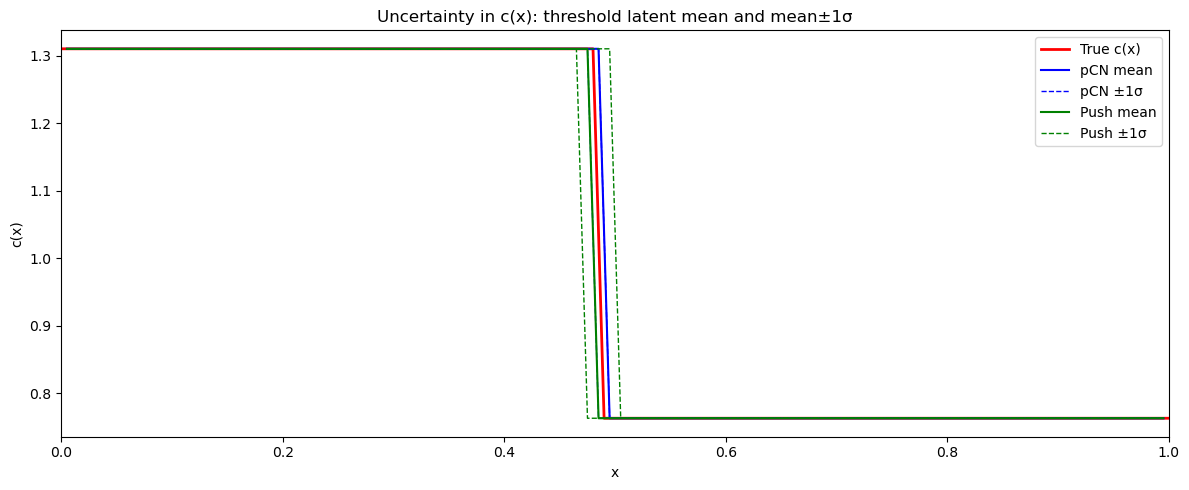

In [42]:
# Threshold mean and mean±std in latent U-space, then map to c(x)
pcn_c_mean  = levelset_to_c_binary(pcn_mean,           c_high, c_low)
pcn_c_upper = levelset_to_c_binary(pcn_mean + pcn_std, c_high, c_low)
pcn_c_lower = levelset_to_c_binary(pcn_mean - pcn_std, c_high, c_low)

push_c_mean  = levelset_to_c_binary(push_mean,            c_high, c_low)
push_c_upper = levelset_to_c_binary(push_mean + push_std, c_high, c_low)
push_c_lower = levelset_to_c_binary(push_mean - push_std, c_high, c_low)

plt.figure(figsize=(12, 5))

plt.plot(x_nodes, c_true, 'r-', lw=2, label="True c(x)")

plt.plot(x_spatial, pcn_c_mean,  'b-',  lw=1.5, label="pCN mean")
plt.plot(x_spatial, pcn_c_upper, 'b--', lw=1,   label="pCN ±1σ")
plt.plot(x_spatial, pcn_c_lower, 'b--', lw=1)

plt.plot(x_spatial, push_c_mean,  'g-',  lw=1.5, label="Push mean")
plt.plot(x_spatial, push_c_upper, 'g--', lw=1,   label="Push ±1σ")
plt.plot(x_spatial, push_c_lower, 'g--', lw=1)

plt.xlabel("x")
plt.ylabel("c(x)")
plt.title("Uncertainty in c(x): threshold latent mean and mean±1σ")
plt.xlim([0, 1])
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
save_path = f"./../../Data/Experiment7/wavespeed_statistics{iter_tag}CM"+str(use_cm)+".npz"

np.savez(
    save_path,
    # sample-wise statistics in c-space
    push_mean_c   = C_push.mean(axis=1),
    push_std_c    = C_push.std(axis=1),
    pcn_mean_c    = C_pcn.mean(axis=1),
    pcn_std_c     = C_pcn.std(axis=1),
    # levelset-thresholded latent mean and bands
    pcn_c_mean    = pcn_c_mean,
    pcn_c_upper   = pcn_c_upper,
    pcn_c_lower   = pcn_c_lower,
    push_c_mean   = push_c_mean,
    push_c_upper  = push_c_upper,
    push_c_lower  = push_c_lower,
    # grids
    x_nodes       = x_nodes,
    x_spatial     = x_spatial,
    c_true        = c_true,
    iteration_data= np.array(iteration_data if iteration_data is not None else -1),
)
print(f"Saved {save_path}")

Saved ./../../Data/Experiment7/wavespeed_statistics_iteration--6CMFalse.npz


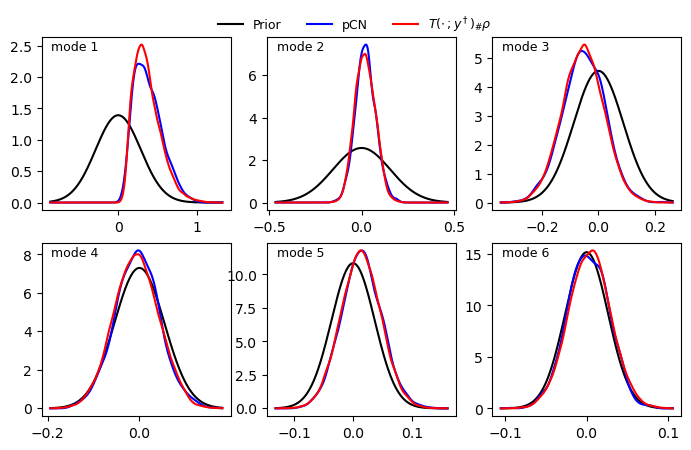

In [44]:
# -----------------------------------------
# Plot first 6 modes only, paper style
# -----------------------------------------
Nmodes_plot = 6

fig, axes = plt.subplots(2, 3, figsize=(6.8, 4.2))
axes = axes.ravel()

for i in range(Nmodes_plot):
    ax = axes[i]

    pcn_i  = pcn_proj[i, :]
    push_i = push_proj[i, :]

    lam_i = lambdas[i]
    std_i = np.sqrt(lam_i)

    all_vals = np.concatenate([pcn_i, push_i])
    x_min = min(all_vals.min(), -3.0 * std_i)
    x_max = max(all_vals.max(),  3.0 * std_i)
    xs = np.linspace(x_min, x_max, 300)

    prior_pdf = (1.0 / (np.sqrt(2*np.pi)*std_i)) * np.exp(-0.5 * (xs/std_i)**2)
    ax.plot(xs, prior_pdf, 'k-', label='Prior')

    kde_pcn = gaussian_kde(pcn_i)
    ax.plot(xs, kde_pcn(xs), 'b-', label='pCN')

    kde_push = gaussian_kde(push_i)
    ax.plot(xs, kde_push(xs), 'r-', label=r'$T(\cdot\,;y^\dagger)_\#\rho$')

    ax.text(0.05, 0.98, f"mode {i+1}",
            transform=ax.transAxes, fontsize=9, va="top")
    ax.tick_params(axis='both')

# Legend outside all axes, centred above the figure
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, frameon=False, fontsize=9,
           loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.06))

plt.tight_layout(pad=0.6)
plt.savefig("./../../Figs/Experiment7/modes_grid_"+strings+"CM"+str(use_cm)+iter_tag+".png",
            dpi=300, bbox_inches="tight")
plt.show()


In [45]:
N = 100 # number of spatial intervals
L=1
dx=L/N
Np1= N+1 # number of grid points including the boundary
i = np.arange(1, N + 1)
x_center = (i - 0.5) / N  # shape (N,) x at the center points
i = np.arange(0, Np1 )
x_nodes = i*dx
# observation:
# --- spatial receivers (indices on x grid) ---
Nr = 10
Nrp2 = Nr+2
i = np.arange(0 , Nrp2)
dx_obs=L/(Nr+1)
ratio_obs_to_discritization= int(dx_obs/dx)
x_nodes_rec = i*dx_obs

recv_idx = (i*ratio_obs_to_discritization)[1:-1]
x_recv = x_nodes[recv_idx]


In [46]:
x_recv

array([0.09, 0.18, 0.27, 0.36, 0.45, 0.54, 0.63, 0.72, 0.81, 0.9 ])

In [47]:
X_obs = x_recv

In [48]:
y_dagger.shape

(10, 1)

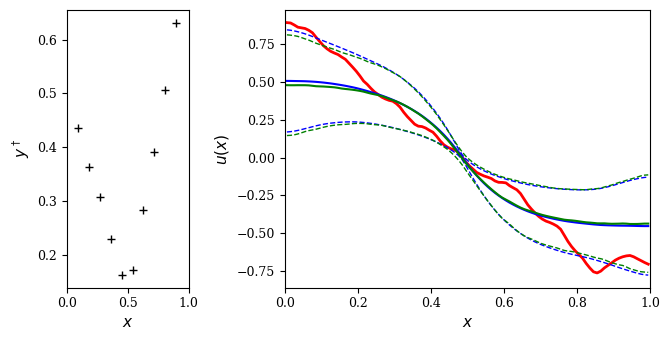

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# Paper font settings
# -----------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
})

# -----------------------------------------
# Means & std
# -----------------------------------------
pcn_mean  = pCNchain.mean(axis=1)
pcn_std   = pCNchain.std(axis=1)

push_mean = pushforward_samples.mean(axis=1)
push_std  = pushforward_samples.std(axis=1)

# -----------------------------------------
# Figure with 25% / 75% width split
# -----------------------------------------
fig = plt.figure(figsize=(6.8, 3.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 3])

ax_obs = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[0, 1])

# -----------------------------------------
# Left subplot: observations
# -----------------------------------------
ax_obs.plot(X_obs, y_dagger, "+", color="k")
ax_obs.set_ylabel(r"$y^\dagger$")
ax_obs.set_xlabel(r"$x$")
ax_obs.set_xlim([0, 1])

# -----------------------------------------
# Right subplot: physical space uncertainty
# -----------------------------------------
ax_main.plot(x_spatial, x_true, 'r-', lw=2, label="True")

ax_main.plot(x_spatial, pcn_mean, 'b-', label="pCN mean")
ax_main.plot(x_spatial, pcn_mean + pcn_std, 'b--', lw=1, label="pCN ±1σ")
ax_main.plot(x_spatial, pcn_mean - pcn_std, 'b--', lw=1)

ax_main.plot(x_spatial, push_mean, 'g-', label="Push mean")
ax_main.plot(x_spatial, push_mean + push_std, 'g--', lw=1, label="Push ±1σ")
ax_main.plot(x_spatial, push_mean - push_std, 'g--', lw=1)

ax_main.set_xlabel(r"$x$")
ax_main.set_ylabel(r"$u(x)$")
ax_main.set_xlim([0, 1])

# ax_main.legend(frameon=False)

# -----------------------------------------
# Layout & save
# -----------------------------------------
plt.tight_layout()
# plt.savefig("./../../Figs/Experiment3/physical_space_with_obs"+strings+"CM"+CM_on_or_off+"+iteration"+str(iteration_data)+".png", dpi=300, bbox_inches='tight')

plt.show()